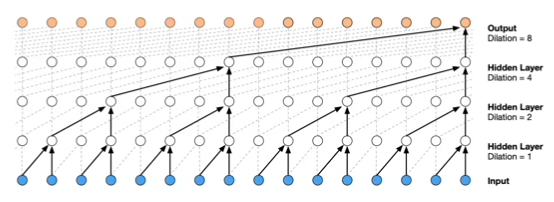

In [12]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [13]:
words = open('../words.txt', 'r').read().splitlines()
words[:8]

['abakus',
 'abandon',
 'abazja',
 'abażur',
 'abażurek',
 'abdukcja',
 'abduktor',
 'abdykacja']

In [14]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

In [15]:
block_size = 8  # context size

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size

        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

In [16]:
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

X_train, Y_train = build_dataset(words[:n1])
X_val, Y_val = build_dataset(words[n1:n2])
X_test, Y_test = build_dataset(words[n2:])

torch.Size([400292, 8]) torch.Size([400292])
torch.Size([50134, 8]) torch.Size([50134])
torch.Size([50015, 8]) torch.Size([50015])


In [17]:
for x, y in zip(X_train[:20], Y_train[:20]):
    print(''.join(itos[ix.item()] for ix in x), '--->', itos[y.item()])

........ ---> e
.......e ---> n
......en ---> d
.....end ---> o
....endo ---> p
...endop ---> r
..endopr ---> o
.endopro ---> t
endoprot ---> e
ndoprote ---> z
doprotez ---> a
oproteza ---> .
........ ---> n
.......n ---> i
......ni ---> e
.....nie ---> k
....niek ---> t
...niekt ---> ó
..niektó ---> r
.niektór ---> y


In [18]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        # out variation = in variation
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)     # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True)    # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []
    

class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    

class Flatten:
    def __call__(self, x):
        self.out = x.view(x.shape[0], -1)
        return self.out
    
    def parameters(self):
        return []
    

class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [19]:
torch.manual_seed(42)

### without scaling

In [20]:
n_emb = 10
n_hidden = 200
model = Sequential([
    Embedding(vocab_size, n_emb),
    Flatten(),
    Linear(n_emb * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))    # number of parameters in total

for p in parameters:
    p.requires_grad = True

23574


In [21]:
max_steps = 300000
batch_size = 32
lossi = []

for i in range(max_steps):
    # construct minibatch
    ix = torch.randint(0, X_train.shape[0], (batch_size,))
    Xb, Yb = X_train[ix], Y_train[ix]

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 300000: 3.5398
  10000/ 300000: 2.2507
  20000/ 300000: 2.1707
  30000/ 300000: 2.4015
  40000/ 300000: 1.5913
  50000/ 300000: 2.1969
  60000/ 300000: 1.9555
  70000/ 300000: 1.6661
  80000/ 300000: 1.5409
  90000/ 300000: 1.6702
 100000/ 300000: 2.0277
 110000/ 300000: 2.1440
 120000/ 300000: 2.1161
 130000/ 300000: 1.2489
 140000/ 300000: 1.6099
 150000/ 300000: 1.5863
 160000/ 300000: 1.4062
 170000/ 300000: 1.6965
 180000/ 300000: 1.6854
 190000/ 300000: 2.0319
 200000/ 300000: 1.6464
 210000/ 300000: 2.0880
 220000/ 300000: 1.9378
 230000/ 300000: 2.1849
 240000/ 300000: 2.3152
 250000/ 300000: 1.6249
 260000/ 300000: 1.7316
 270000/ 300000: 1.8367
 280000/ 300000: 1.5960
 290000/ 300000: 2.0561


In [22]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (X_train, Y_train),
        'val': (X_val, Y_val),
        'test': (X_test, Y_test),
    }[split]

    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.7966159582138062
val 1.8436652421951294


### with wavenet

In [23]:
n_emb = 10
n_hidden = 200
model = Sequential([
    Embedding(vocab_size, n_emb),
    Flatten(),
    Linear(n_emb * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))    # number of parameters in total

for p in parameters:
    p.requires_grad = True

23574


In [24]:
ix = torch.randint(0, X_train.shape[0], (4,))
Xb, Yb = X_train[ix], Y_train[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[15, 16,  1,  7,  1, 14,  4,  1],
        [ 0,  0,  0,  0,  0,  0,  0, 18],
        [17, 24,  5, 18, 24, 14,  9, 11],
        [ 0,  0,  9, 14, 11, 15, 14,  7]])

In [25]:
model.layers[0].out.shape

torch.Size([4, 8, 10])

In [26]:
model.layers[1].out.shape

torch.Size([4, 80])

In [27]:
model.layers[2].out.shape

torch.Size([4, 200])

In [28]:
(torch.randn(4, 80) @ torch.randn(80, 200) + torch.randn(200)).shape

torch.Size([4, 200])

now we want 2\*10=20, not 8\*10=80

In [29]:
# (1 2) (3 4) (5 6) (7 8)

In [30]:
(torch.randn(4, 4, 80) @ torch.randn(80, 200) + torch.randn(200)).shape
# (4 examples in a batch) x (8/2) x (2*10)

torch.Size([4, 4, 200])

In [31]:
e = torch.randn(4, 8, 10)       # goal: (4, 4, 20)      shape of model.layers[0].out.shape
e.view(4, 4, 20).shape

torch.Size([4, 4, 20])

In [36]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        # out variation = in variation
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)     # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True)    # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []
    

class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    

class FlattenConsecutive:
    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape       # (batch_size, block_size, emb_size)
        x = x.view(B, T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out
    
    def parameters(self):
        return []
    

class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

### 8 entries, so nothing changes

In [37]:
n_emb = 10
n_hidden = 200
model = Sequential([
    Embedding(vocab_size, n_emb),
    FlattenConsecutive(block_size),
    Linear(n_emb * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))    # number of parameters in total

for p in parameters:
    p.requires_grad = True

23574


In [38]:
ix = torch.randint(0, X_train.shape[0], (4,))
Xb, Yb = X_train[ix], Y_train[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  0,  0,  0, 16],
        [ 0,  0,  0,  0,  9, 24, 15,  6],
        [18,  9, 26, 11, 12,  9, 22, 15],
        [ 0,  0,  0,  0,  0,  0, 24,  7]])

In [39]:
for layer in model.layers:
    print(layer.__class__.__name__,":", tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 80)
Linear : (4, 200)
BatchNorm1d : (4, 200)
Tanh : (4, 200)
Linear : (4, 34)


### 2 entries, like in wavenet

In [40]:
n_emb = 10
n_hidden = 68       # so that the number of parameters is the same as before
model = Sequential([
    Embedding(vocab_size, n_emb),
    FlattenConsecutive(2), Linear(n_emb * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))    # number of parameters in total

for p in parameters:
    p.requires_grad = True

22950


In [41]:
ix = torch.randint(0, X_train.shape[0], (4,))
Xb, Yb = X_train[ix], Y_train[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[24,  1, 17, 15, 22, 23, 22,  1],
        [ 0,  0, 20, 18, 11, 17, 24, 23],
        [ 0, 11, 17, 23, 16, 19, 15, 16],
        [ 7, 12,  9, 14, 15, 11, 17, 24]])

In [42]:
for layer in model.layers:
    print(layer.__class__.__name__,":", tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 68)
BatchNorm1d : (4, 4, 68)
Tanh : (4, 4, 68)
FlattenConsecutive : (4, 2, 136)
Linear : (4, 2, 68)
BatchNorm1d : (4, 2, 68)
Tanh : (4, 2, 68)
FlattenConsecutive : (4, 136)
Linear : (4, 68)
BatchNorm1d : (4, 68)
Tanh : (4, 68)
Linear : (4, 34)


In [43]:
model.layers[3].running_mean.shape

torch.Size([1, 4, 68])

In [44]:
max_steps = 300000
batch_size = 32
lossi = []

for i in range(max_steps):
    # construct minibatch
    ix = torch.randint(0, X_train.shape[0], (batch_size,))
    Xb, Yb = X_train[ix], Y_train[ix]

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 300000: 3.5070
  10000/ 300000: 2.0769
  20000/ 300000: 2.1414
  30000/ 300000: 2.1107
  40000/ 300000: 2.0083
  50000/ 300000: 2.2086
  60000/ 300000: 1.6223
  70000/ 300000: 1.6284
  80000/ 300000: 1.7953
  90000/ 300000: 1.8769
 100000/ 300000: 2.1846
 110000/ 300000: 2.2155
 120000/ 300000: 2.2868
 130000/ 300000: 1.5414
 140000/ 300000: 2.2518
 150000/ 300000: 1.9014
 160000/ 300000: 1.8638
 170000/ 300000: 1.7726
 180000/ 300000: 1.7882
 190000/ 300000: 2.0662
 200000/ 300000: 2.0376
 210000/ 300000: 1.7411
 220000/ 300000: 1.9999
 230000/ 300000: 1.9054
 240000/ 300000: 1.7962
 250000/ 300000: 2.2946
 260000/ 300000: 1.6137
 270000/ 300000: 2.0708
 280000/ 300000: 1.7109
 290000/ 300000: 1.5359


In [45]:
split_loss('train')
split_loss('val')

train 1.7991962432861328
val 1.831814169883728


### bug fix
in BachNorm1d \__call__ x should be 2d, but it is 3d now

3d because we want to also normalize by positions tgo prevent the model from learning simple statistics over positions

In [48]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        # out variation = in variation
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # forward pass
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0, 1)
            xmean = x.mean(dim, keepdim=True)     # batch mean
            xvar = x.var(dim, keepdim=True)    # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []
    

class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    

class FlattenConsecutive:
    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape       # (batch_size, block_size, emb_size)
        x = x.view(B, T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out
    
    def parameters(self):
        return []
    

class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [49]:
n_emb = 10
n_hidden = 68       # so that the number of parameters is the same as before
model = Sequential([
    Embedding(vocab_size, n_emb),
    FlattenConsecutive(2), Linear(n_emb * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))    # number of parameters in total

for p in parameters:
    p.requires_grad = True

22950


In [50]:
max_steps = 300000
batch_size = 32
lossi = []

for i in range(max_steps):
    # construct minibatch
    ix = torch.randint(0, X_train.shape[0], (batch_size,))
    Xb, Yb = X_train[ix], Y_train[ix]

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    break

      0/ 300000: 3.5254


In [51]:
for layer in model.layers:
    print(layer.__class__.__name__,":", tuple(layer.out.shape))

Embedding : (32, 8, 10)
FlattenConsecutive : (32, 4, 20)
Linear : (32, 4, 68)
BatchNorm1d : (32, 4, 68)
Tanh : (32, 4, 68)
FlattenConsecutive : (32, 2, 136)
Linear : (32, 2, 68)
BatchNorm1d : (32, 2, 68)
Tanh : (32, 2, 68)
FlattenConsecutive : (32, 136)
Linear : (32, 68)
BatchNorm1d : (32, 68)
Tanh : (32, 68)
Linear : (32, 34)


In [52]:
model.layers[3].running_mean.shape

torch.Size([1, 1, 68])

In [53]:
max_steps = 300000
batch_size = 32
lossi = []

for i in range(max_steps):
    # construct minibatch
    ix = torch.randint(0, X_train.shape[0], (batch_size,))
    Xb, Yb = X_train[ix], Y_train[ix]

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 300000: 3.5082
  10000/ 300000: 2.1061
  20000/ 300000: 2.1575
  30000/ 300000: 2.0204
  40000/ 300000: 1.9408
  50000/ 300000: 1.9338
  60000/ 300000: 2.1565
  70000/ 300000: 1.9321
  80000/ 300000: 2.0142
  90000/ 300000: 1.6679
 100000/ 300000: 1.8925
 110000/ 300000: 1.7254
 120000/ 300000: 1.7479
 130000/ 300000: 1.8077
 140000/ 300000: 1.6679
 150000/ 300000: 2.1974
 160000/ 300000: 1.8283
 170000/ 300000: 2.0962
 180000/ 300000: 2.0890
 190000/ 300000: 1.7140
 200000/ 300000: 1.8680
 210000/ 300000: 1.7006
 220000/ 300000: 1.5090
 230000/ 300000: 1.2117
 240000/ 300000: 2.2174
 250000/ 300000: 2.1137
 260000/ 300000: 2.0166
 270000/ 300000: 1.6671
 280000/ 300000: 1.6547
 290000/ 300000: 1.8450


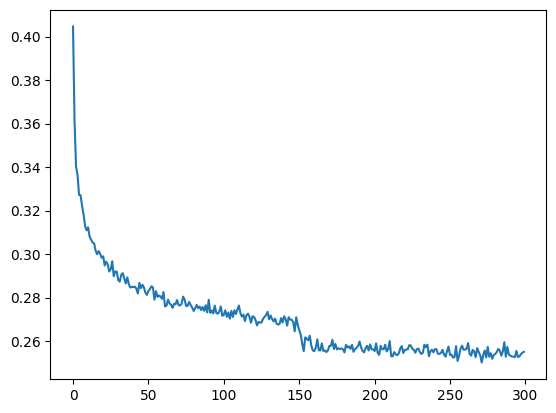

In [54]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [55]:
for layer in model.layers:
    layer.training = False

In [56]:
split_loss('train')
split_loss('val')

train 1.7725393772125244
val 1.815195918083191


### scaling

In [ ]:
n_emb = 24
n_hidden = 128
model = Sequential([
    Embedding(vocab_size, n_emb),
    FlattenConsecutive(2), Linear(n_emb * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))    # number of parameters in total

for p in parameters:
    p.requires_grad = True

77650


In [60]:
max_steps = 300000
batch_size = 32
lossi = []

for i in range(max_steps):
    # construct minibatch
    ix = torch.randint(0, X_train.shape[0], (batch_size,))
    Xb, Yb = X_train[ix], Y_train[ix]

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 300000: 3.4366
  10000/ 300000: 1.7967
  20000/ 300000: 1.5632
  30000/ 300000: 2.0012
  40000/ 300000: 1.5768
  50000/ 300000: 1.6523
  60000/ 300000: 1.4634
  70000/ 300000: 2.0715
  80000/ 300000: 1.7595
  90000/ 300000: 1.8016
 100000/ 300000: 1.9535
 110000/ 300000: 2.0606
 120000/ 300000: 1.4141
 130000/ 300000: 1.7247
 140000/ 300000: 1.7547
 150000/ 300000: 1.4862
 160000/ 300000: 1.7087
 170000/ 300000: 1.4038
 180000/ 300000: 1.5285
 190000/ 300000: 1.2485
 200000/ 300000: 1.5590
 210000/ 300000: 1.9431
 220000/ 300000: 1.3900
 230000/ 300000: 2.0134
 240000/ 300000: 1.8637
 250000/ 300000: 1.7373
 260000/ 300000: 1.8637
 270000/ 300000: 1.7121
 280000/ 300000: 1.6972
 290000/ 300000: 1.5774


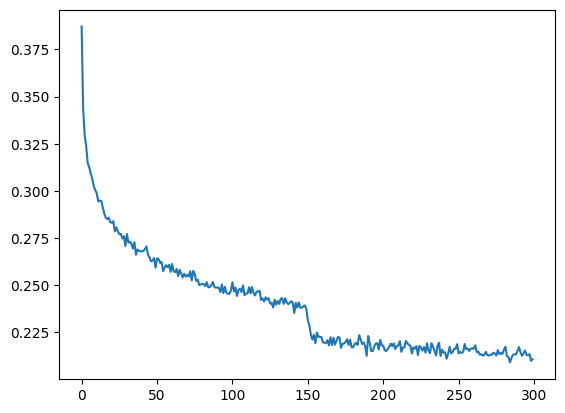

In [61]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [62]:
for layer in model.layers:
    layer.training = False

In [63]:
split_loss('train')
split_loss('val')

train 1.6092654466629028
val 1.7202504873275757


In [64]:
g = torch.Generator().manual_seed(2147483647+10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out))

cyłogistyca.
chronon.
odprasowanie.
ekompencja.
kormatyzracja.
przełączenie.
żekonitielacha.
inwekratyczność.
iziofilimowanie.
preodomant.
rzedawój.
tap.
uzajni.
zlerek.
łóż.
oddzięcie.
rozmazanie.
rozproedzistka.
gruchesja.
żywicowa.
